In [1]:
from google.colab import files
import io

uploaded = files.upload()

Saving xgb_model (1).pkl to xgb_model (1).pkl
Saving xgb_results.csv to xgb_results.csv
Saving lr_model (1).pkl to lr_model (1).pkl
Saving lr_scaler (1).pkl to lr_scaler (1).pkl
Saving lr_results.csv to lr_results.csv


In [2]:
# ── CÉLULA 1 · Setup e carga ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import roc_curve, confusion_matrix

sns.set_theme(style='whitegrid', palette='muted')

# Resultados consolidados
df_lr  = pd.read_csv('/content/lr_results.csv')
df_xgb = pd.read_csv('/content/xgb_results.csv')

df_results = pd.concat([df_lr, df_xgb], ignore_index=True)

print("=== RESULTADOS BASELINE (100% dos dados) ===")
print(df_results.to_string(index=False))

=== RESULTADOS BASELINE (100% dos dados) ===
            modelo subsample  acuracia  precisao   recall       f1  roc_auc
LogisticRegression    100pct  0.672451  0.705706 0.535308 0.608808 0.720207
           XGBoost    100pct  0.664859  0.663317 0.601367 0.630824 0.721362


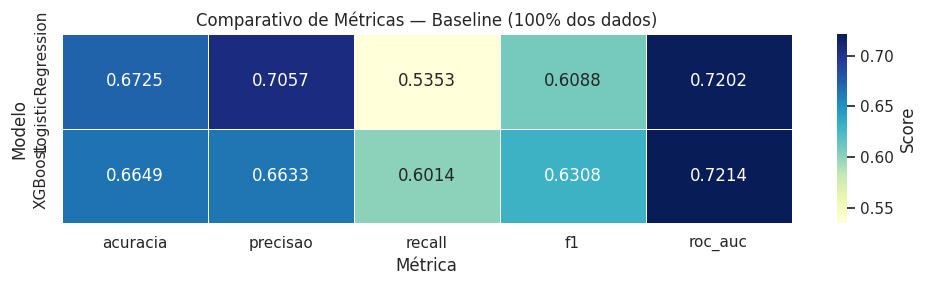


=== DIFERENÇA (XGBoost - LogisticRegression) ===
  acuracia: -0.0076
  precisao: -0.0424
  recall: +0.0661
  f1: +0.0220
  roc_auc: +0.0012


In [3]:
# ── CÉLULA 2 · Tabela comparativa ─────────────────────────────────

metrics_cols = ['acuracia', 'precisao', 'recall', 'f1', 'roc_auc']

df_comp = df_results[['modelo'] + metrics_cols].set_index('modelo')

# Heatmap-tabela
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    df_comp,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Score'}
)
ax.set_title('Comparativo de Métricas — Baseline (100% dos dados)', fontsize=12)
ax.set_xlabel('Métrica')
ax.set_ylabel('Modelo')
plt.tight_layout()
plt.savefig('/content/comparativo_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

# Diferenças absolutas
print("\n=== DIFERENÇA (XGBoost - LogisticRegression) ===")
diff = df_comp.loc['XGBoost'] - df_comp.loc['LogisticRegression']
for col, val in diff.items():
    sinal = '+' if val >= 0 else ''
    print(f"  {col}: {sinal}{val:.4f}")

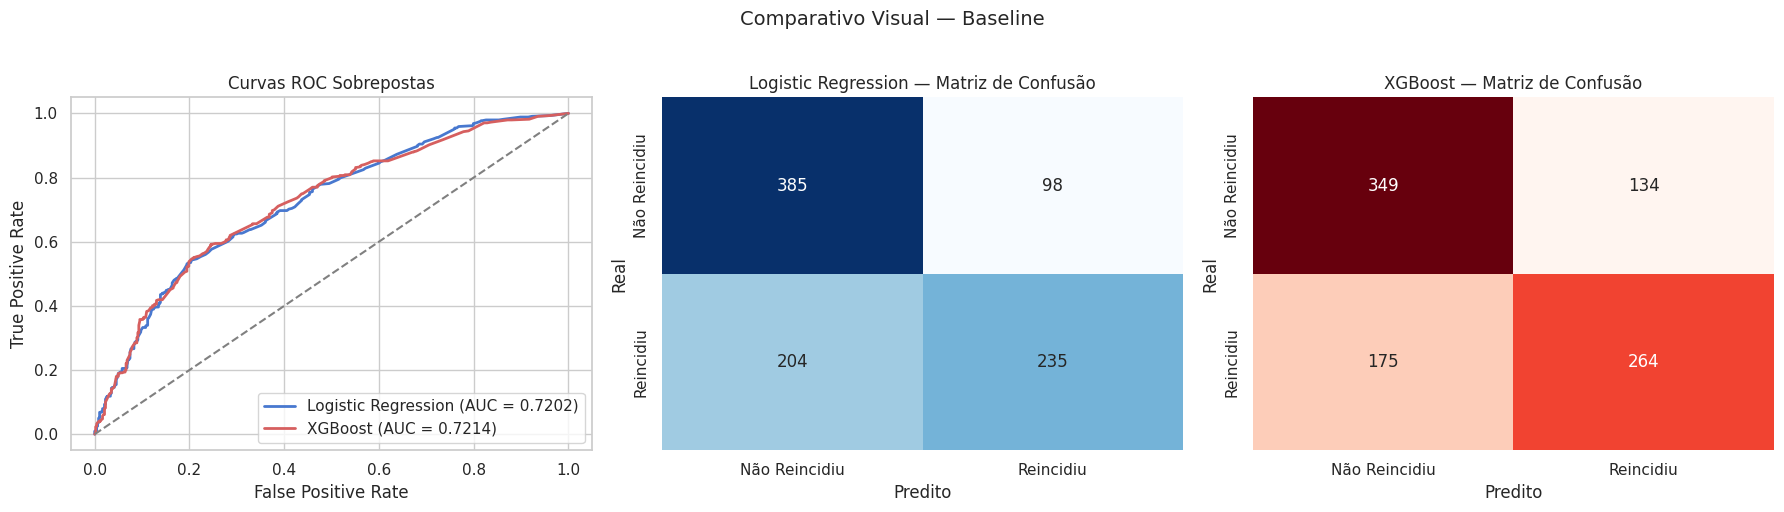

In [5]:
# ── CÉLULA 3 · Curvas ROC + matrizes de confusão ──────────────────

# Carregar modelos e dados de teste
with open('/content/lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)
with open('/content/lr_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('/content/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Recarregar dados de teste com mesmo split usado nos modelos
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/compas_prepared.csv')

FEATURES = [
    'sex_encoded', 'age_cat_encoded', 'race_encoded',
    'juv_fel_count', 'juv_misd_count', 'juv_other_count',
    'priors_count', 'c_charge_degree_encoded',
]
NUMERIC_FEATURES = ['juv_fel_count', 'juv_misd_count',
                    'juv_other_count', 'priors_count']

X = df[FEATURES]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar scaler nas features numéricas (apenas para LR)
X_test_scaled = X_test.copy()
X_test_scaled[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

# Predições
lr_prob   = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred   = lr_model.predict(X_test_scaled)
xgb_prob  = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. ROC sobrepostas
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

axes[0].plot(fpr_lr, tpr_lr, color='#4878CF', lw=2,
             label=f"Logistic Regression (AUC = {df_comp.loc['LogisticRegression','roc_auc']:.4f})")
axes[0].plot(fpr_xgb, tpr_xgb, color='#D65F5F', lw=2,
             label=f"XGBoost (AUC = {df_comp.loc['XGBoost','roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('Curvas ROC Sobrepostas')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# 3b. Matriz de confusão LR
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Reincidiu', 'Reincidiu'],
            yticklabels=['Não Reincidiu', 'Reincidiu'],
            ax=axes[1], cbar=False)
axes[1].set_title('Logistic Regression — Matriz de Confusão')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

# 3c. Matriz de confusão XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Não Reincidiu', 'Reincidiu'],
            yticklabels=['Não Reincidiu', 'Reincidiu'],
            ax=axes[2], cbar=False)
axes[2].set_title('XGBoost — Matriz de Confusão')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')

plt.suptitle('Comparativo Visual — Baseline', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/comparativo_visual.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── CÉLULA 4 · Síntese e exportação ───────────────────────────────

df_results.to_csv('/content/all_results.csv', index=False)

print("=" * 65)
print("SÍNTESE — COMPARATIVO BASELINE")
print("=" * 65)
print(f"""
Os dois modelos apresentam performance equivalente no teste:

  • Logistic Regression: ROC-AUC = {df_comp.loc['LogisticRegression','roc_auc']:.4f}
  • XGBoost            : ROC-AUC = {df_comp.loc['XGBoost','roc_auc']:.4f}
  • Diferença          : {(df_comp.loc['XGBoost','roc_auc'] - df_comp.loc['LogisticRegression','roc_auc']):+.4f}

A convergência reproduz achados da literatura (Dressel & Farid, 2018;
Biecek et al., 2020), confirmando que o dataset COMPAS apresenta um
teto informacional em torno de AUC ≈ 0.72, independentemente da
complexidade do modelo.

Esses resultados validam ambos os modelos como ponto de referência
para o experimento de subsampling progressivo da diversidade racial.
""")
print("=" * 65)
print("\n Exportados:")
print("   all_results.csv")
print("   comparativo_metricas.png")
print("   comparativo_visual.png")